# MVP -  Machine Learning e Analytics

**Autora:** Ligia R. Vieira  

**Matrícula:** 1200158

**Data:** Junho/2026


**Dataset:** [Stock Market Trends and Investor Sentiment](https://www.kaggle.com/datasets/dastgeerjutt/stock-market-trends-and-investor-sentiment?resource=download)

**Tipo de problema:** Classificação

# Definição do Problema

O mercado financeiro é influenciado diariamente por diversos fatores econômicos, políticos e comportamentais que interferem nos preços dos ativos. Tradicionalmente, os agentes do mercado financeiro tomavam as suas decisões baseadas em três pilares: Análise Fundamentalista, Análise Gráfica e Informações Econômicas e Notícias.


No contexto atual, temos o crescimento exponencial da disponibilização de dados que aliado à aplicação de modelos de Machine Learning possibilita a geração de previsões sobre o comportamento dos ativos.


Essa solução atenderia aos diversos agentes do mercado: Investidores, Analistas e Gestores Financeiros.


A relevância do problema está na possibilidade de gerar um dado de preditivo em informação útil para auxiliar decisões financeiras.
<br>
## Objetivo

O objetivo deste projeto é construir e avaliar um modelo de **<i>Classificação Binária**</i> utilizando o Dataset<i> Stock Market Trends and Investor Sentiment</i> para prever se o preço de um ativo financeiro apresentará alta ou baixa no período seguinte.

## Tipo do Problema

O Dataset possui algumas variáveis históricas:

Variáveis de preço:<br>

- open_price (preço de abertura)<br>
- high_price (preço máximo do período)<br>
- low_price(preço mínimo do período)<br>
- close_price (preço de fechamento)<br>

Volume negociações:<br>

- volume (quantidade negociada)<br>



Uma variável alvo (target) definida pode resultar em apenas duas categorias possíveis:

1 (Alta) → quando o preço de fechamento seguinte for superior ao preço do período atual.<br>
0 (Baixa) → quando o preço de fechamento seguinte for inferior ao preço do período atual.

Com isso, o problema proposto neste projeto é caracterizado como <i><u>Classificação Supervisionada Binária</u></i>.

Observação: Futuramente pretende-se explorar técnicas de Séries Temporais, mais adequadas à natureza dos dados, para enriquecimento do portfólio no GitHub.
<br><br>


# Hipóteses do Problema

1 - Os atributos de preço (open_price, high_price, low_price e close_price) contêm padrões históricos capazes de ajudar na previsão da direção do preço de fechamento no período seguinte.<br>
2 - O atributo market_sentiment melhora a capacidade do modelo de classificar a direção futura do preço.<br>
3 - O atributo volume contribui para identificar movimentos de alta ou baixa dos ativos.<br>
4 - A variável date pode conter padrões temporais relevantes para a previsão da direção do preço dos ativos.<br>
5 - A variável company pode capturar diferenças de comportamento entre os ativos, contribuindo para a classificação entre Alta (1) e Baixa (0).<br>


Como critério de sucesso, a métrica principal será o F1-score, pois o problema é de classificação binária e pode haver desbalanceamento entre classes (Alta e Baixa). O F1-score permite avaliar o equilíbrio entre precisão e recall, sendo mais adequado do que apenas accuracy.

# Ambiente, bibliotecas e reprodutibilidade


Este projeto foi desenvolvido em ambiente Python, utilizando o Google Colab para execução do notebook.

Também foram utilizadas bibliotecas mais utilizadas na área de Ciência de Dados como: Pandas, NumPy, Matplotlib, Seaborn e Scikit-learn.

A reprodutibilidade foi garantida pela definição de seed aleatória, uso de bibliotecas padrão necessárias em um pipeline com: carga dos dados, pré-processamento, modelagem e avaliação.

In [105]:


# man. dados
import pandas as pd
import numpy as np

# visu.
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Pré-processamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# modelo
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline


# metricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Cconf.
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Seleção e carga dos dados

O Dataset escolhido foi obtido no repositório Kaggle, sendo um conjunto de dados público e previamente estruturado. Dessa forma, o foco do trabalho concentra-se na execução do fluxo de aprendizado de máquina.
<br><br>
Link de acesso: https://www.kaggle.com/datasets/dastgeerjutt/stock-market-trends-and-investor-sentiment

Este Dataset foi escolhido por estar inserido no contexto do mercado financeiro, uma área de grande abrangência e relevância global, além de possibilitar a aplicação de técnicas de Machine Learning para gerar previsões sobre o comportamento dos ativos.

<b>A princípio, não existe restrições/condições...</b>

## Carga dos dados


In [106]:
# Acesso ao Dataset pelo Github

url = "https://raw.githubusercontent.com/Vieiraligia/Data-Science-and-Analytics/main/MVP%20Machine%20Learning%20e%20Analytics/stock_market_trends_5000.csv"

df = pd.read_csv(url)

In [107]:
display(HTML("<h3 style='text-align:center;'>Primeiras 7 linhas do Dataset</h3>"))
df.head(7)

,date,company,open_price,high_price,low_price,close_price,volume,market_sentiment
0,2015-01-01,Tesla,1305.33,75.86,966.61,1457.35,25927814,Bearish
1,2015-01-02,Google,391.80,686.82,593.58,883.22,22040434,Neutral
2,2015-01-03,Netflix,985.74,1275.50,1253.30,1131.63,36551427,Bullish
3,2015-01-04,Amazon,514.78,299.75,441.69,222.58,43823086,Bullish
4,2015-01-05,Amazon,779.04,657.66,1301.97,1453.85,38410461,Neutral
5,2015-01-06,Tesla,408.37,1098.67,1081.54,698.39,3531470,Neutral
6,2015-01-07,Google,89.33,789.22,809.52,1241.98,46672942,Bullish


## Atributos do Dataset


Variável temporal:<br>

- date → variável do tipo data/hora

Variável categórica:<br>
- company → variável categórica

Variáveis numéricas - features:<br>

- open_price (preço de abertura) → variável numérica contínua (float)<br>
- high_price (preço máximo do período) → variável numérica contínua (float)<br>
- low_price(preço mínimo do período) → variável numérica contínua (float)<br>
- close_price (preço de fechamento) → variável numérica contínua (float)<br>
- volume (quantidade negociada)→ variável numérica contínua (integer)<br>

Sentimento de mercado:<br>

- market_sentiment → variável categórica
<br>


##Total e Tipo das Instâncias

In [108]:
print("Total de instâncias:", len(df))
print("Total de atributos:", len(df.columns))
print("Tipos de dados: \n")

display(df.dtypes.to_frame("tipo"))

Total de instâncias: 5000
Total de atributos: 8
Tipos de dados: 



,tipo
date,object
company,object
open_price,float64
high_price,float64
low_price,float64
close_price,float64
volume,int64
market_sentiment,object


In [109]:
display(HTML("<h3 style='text-align:center;'>Verificação dos Dados</h3>"))

display(HTML("<h4>Valores Nulos</h4>"))
display(df.isna().sum())

display(HTML("<h4>Registros Duplicados:</h4>"))
display(df.duplicated().sum())

,0
date,0
company,0
open_price,0
high_price,0
low_price,0
close_price,0
volume,0
market_sentiment,0


np.int64(0)

A verificação realizada indica que não há valores ausentes em nenhum dos atributos e também não foram identificadas instâncias duplicadas no conjunto de dados.

In [110]:
 SEED = 1
display(df.sample(5, random_state=SEED))

,date,company,open_price,high_price,low_price,close_price,volume,market_sentiment
2764,2022-07-27,Amazon,508.65,551.90,1008.53,1247.64,37916291,Bullish
4767,2028-01-20,Apple,620.33,880.41,174.75,1138.44,31653727,Bullish
3814,2025-06-11,Meta,892.70,1192.14,1436.08,494.28,43863433,Bullish
3499,2024-07-31,Apple,138.42,1490.63,1133.23,1241.19,28785789,Bearish
2735,2022-06-28,Tesla,1095.47,585.32,1120.09,662.42,639421,Bullish


## Dicionário de Dados


| Coluna | Tipo  | Descrição  | Será usada no modelo? | Observações |
|---|---|---|---|---|
| date  | data | Data da observação do ativo financeiro                                   | Sim           | Usada para ordenação temporal e possível feature engineering |
| company  | categórica | Identificador da empresa/ativo  | Sim    | - |
| open_price   | numérica  | Preço de abertura do ativo no período  | Sim | Dados de preço  |
| high_price  | numérica | Maior preço atingido no período | Sim  | - |
| low_price  | numérica | Menor preço atingido no período   | Sim  | - |
| close_price  | numérica | Preço de fechamento do ativo  | Sim  | Base para o target |
| volume   | numérica | Volume de negociações realizadas | Sim  | - |
| market_sentiment | categórica/numérica | Indicador de sentimento do mercado    | Sim   | Talvez tenha encoding ou normalização |
| target  | binária (alvo)  | 1 = valorização do ativo, 0 = desvalorização ou estabilidade  | Alvo  | Dado que o modelo irá prever |

# Análise Exploratória dos Dados

Neste projeto, a Análise Exploratória de Dados tem por objetivo compreender a estrutura, a qualidade e as características dos dados, identificando aspectos erlevantes para a construção do modelo de Classificação Binária.

Mais especificamente, como mencionado na definição do problema, visa identificar quais variáveis apresentam características que podem ajudar o modelo a prever se o preço do ativo irá subir ou cair no próximo período.

Para isso, serão analisadas:
- Distribuição da variável alvo (Target).
- Distribuição das variáveis numéricas.
- Relação entre variáveis e o Target.
- Desbalanceamento, outliers ou padrões relevantes.

###Distribuição da variável alvo (Target)

In [111]:
df['company'].value_counts()

,count
company,
Meta,758
Apple,735
Microsoft,723
Amazon,707
Netflix,706
Google,699
Tesla,672


In [112]:
df.groupby('company')['date'].agg(['min', 'max', 'count'])

,min,max,count
company,,,
Amazon,2015-01-04,2028-09-08,707
Apple,2015-01-09,2028-09-04,735
Google,2015-01-02,2028-09-07,699
Meta,2015-01-26,2028-09-05,758
Microsoft,2015-01-12,2028-08-26,723
Netflix,2015-01-03,2028-09-01,706
Tesla,2015-01-01,2028-09-06,672


Essa relação 'date' e 'company' mostra que cada empresa possui um histórico próprio de registros ao longo do tempo.

Embora a quantidade de observações varie entre as empresas, todas apresentam uma sequência temporal entre os anos de 2015 e 2028.

Dessa forma, a construção da variável Target deve considerar a evolução do preço de fechamento dentro da própria empresa, comparando o preço de um período com o período seguinte do mesmo ativo.


In [113]:
df = df.sort_values(['company', 'date']).reset_index(drop=True)

In [114]:
# Criação da variável alvo
# 1 = preço de fechamento do próximo período > que o atual
# 0 = preço de fechamento do próximo período <= ou igual ao atual

df = df.sort_values(["company", "date"])

df["Target"] = (
    df.groupby("company")["close_price"].shift(-1) >
    df["close_price"]
).astype(int)

df = df.dropna(subset=["Target"])

In [115]:
# Frequência das classes em % e total

target_summary = pd.DataFrame({
    "Frequência": df["Target"].value_counts().sort_index(),
    "Percentual (%)": (df["Target"].value_counts(normalize=True).sort_index() * 100).round(2)
})

# Renomear os índices de forma explícita e segura
target_summary.index = target_summary.index.map({
    0: "Baixa (0)",
    1: "Alta (1)"
})

target_summary

,Frequência,Percentual (%)
Target,,
Baixa (0),2530,50.6
Alta (1),2470,49.4


A variável Target foi criada para representar a direção do preço de fechamento no período seguinte de cada empresa. Para isso, os registros foram ordenados por empresa e data, garantindo a sequência temporal de cada ativo. Em seguida, o preço de fechamento de cada período foi comparado com o preço de fechamento do período imediatamente seguinte da mesma empresa.


Quando o preço de fechamento do período seguinte foi maior que o do período atual, a observação recebeu o valor 1 (Alta). Caso contrário, recebeu o valor 0 (Baixa). Como a última observação de cada empresa não possui um período subsequente para comparação, esses registros foram removidos do conjunto de dados.

Como o problema consiste em uma classificação binária, o desempenho do modelo será avaliado por meio das métricas de Acurácia e F1-score, que permitem medir a capacidade do modelo em classificar corretamente os movimentos de alta e baixa do preço dos ativos.


### Variáveis Numéricas x Target

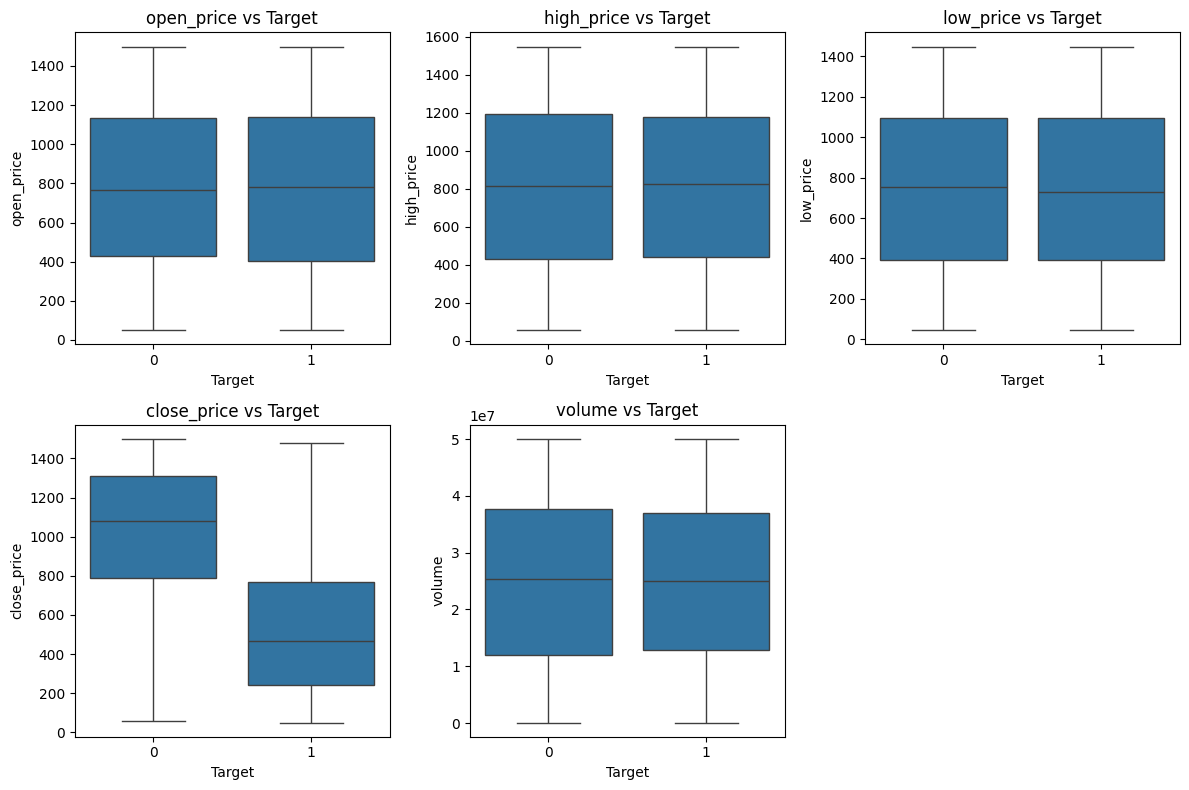

In [116]:
features = ["open_price", "high_price", "low_price", "close_price", "volume"]

df_plot = df.copy()

plt.figure(figsize=(12, 8))

for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df_plot, x="Target", y=col)
    plt.title(f"{col} vs Target")

plt.tight_layout()
plt.show()

Percebe-se que os atributos <i> '<b>open_price</b>'</i>, <i>'<b>high_price</b>'</i> e<i> '<b>low_price</b>' </i> apresentam distribuições semelhantes entre as classes Alta (1) e Baixa (0), sem muita distinção entre os grupos.

Porém, o <i>'<b>close_price</b>'</i> apresenta uma diferença mais evidente entre as distribuições das classes. Isso é esperado, uma vez que a variável Target foi construída com base na variação futura do preço de fechamento, o que pode induzir uma relação direta entre o valor atual e a direção do movimento.

Analistando o <i>'<b>volume</b>'</i> as distribuições são praticamente iguais entre as classes, apresentando uma grande sobreposição.

No contexto geral, os resultados indicam que não há separação linear entre as classes com base apenas em variáveis individuais, reforçando a necessidade de modelo de Machine Learning capaz de obter relações mais complexas entre os atributos.



### Relação entre variável market_sentiment e Target

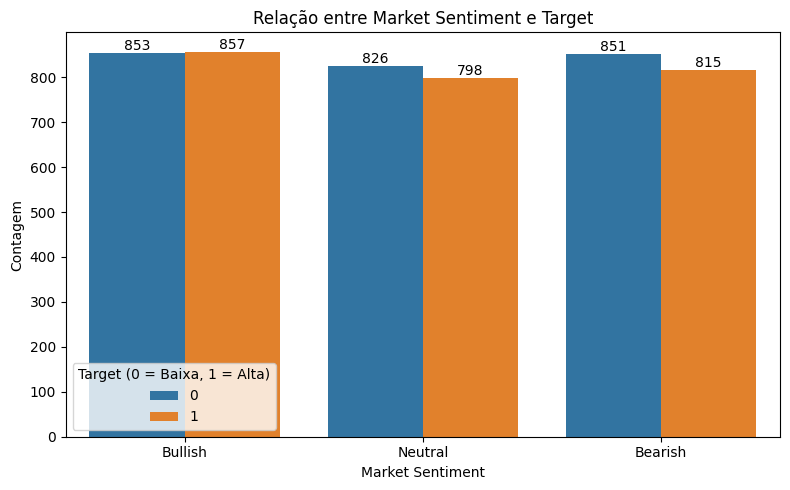

In [117]:

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="market_sentiment",
    hue="Target"
)

plt.title("Relação entre Market Sentiment e Target")
plt.xlabel("Market Sentiment")
plt.ylabel("Contagem")
plt.legend(title="Target (0 = Baixa, 1 = Alta)")

# Adiciona valores nas barras
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

Nesse gráfico, observa-se que as frequências das categorias <i>'<b>Bearish</b>'</i>,<i>'<b>Neutral</b>'</i> e </i>'<b>Bullish</b>'</i> são bastante próximas entre as classes da variável Target. Esse comportamento não evidencia diferenças significativas que permitam associar diretamente o sentimento de mercado à direção futura do preço dos ativos.


### Relação entre a variável company e Target

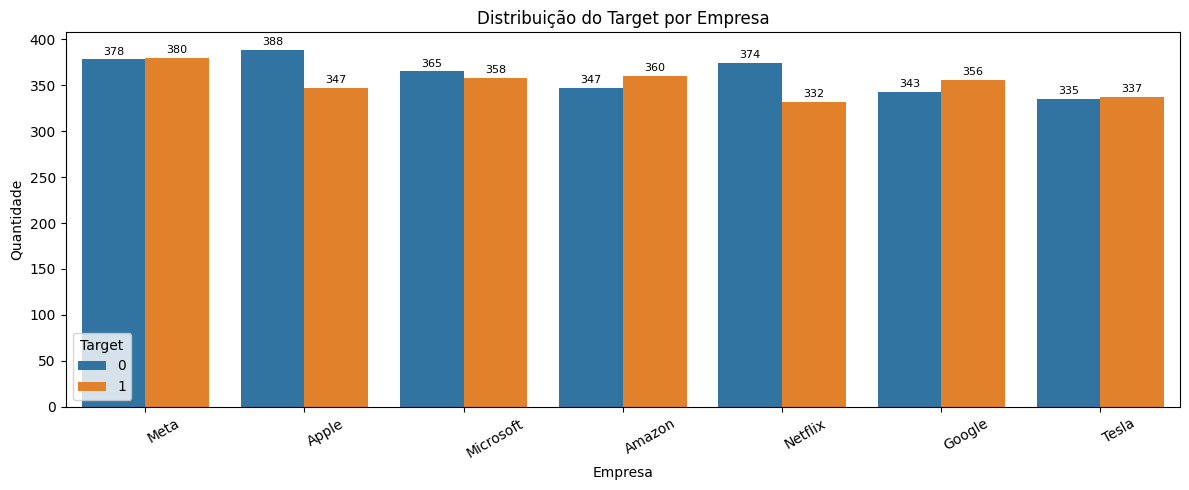

In [118]:
# Ordena as empresas pela quantidade total de registros
order = (
    df["company"]
    .value_counts()
    .index
)

plt.figure(figsize=(12,5))

ax = sns.countplot(
    data=df,
    x="company",
    hue="Target",
    order=order
)

# Adiciona os valores sobre as barras
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        fontsize=8,
        padding=2
    )

plt.title("Distribuição do Target por Empresa")
plt.xlabel("Empresa")
plt.ylabel("Quantidade")

plt.xticks(rotation=30, ha="left")

plt.tight_layout()
plt.show()

O Dataset é composto por 7 empresas, e o gráfico mostra a distribuição da variável Target para cada uma delas. Em todas, observa-se um volume semelhante de registros, com distribuição relativamente equilibrada entre as classes Alta (1) e Baixa (0), ainda que possam existir pequenas variações entre os ativos.

Em algumas empresas, nota-se leve predominância da classe Alta, enquanto em outras há uma leve tendência à classe Baixa. No entanto, essas diferenças são pouco expressivas.

De forma geral, as diferenças são bem pequenas, indicando que a variável <i><b>company</b></i> isoladamente não é suficiente para diferenciar a direção do preço. Mas ainda assim, pode contribuir para o modelo ao representar características específicas de cada ativo em conjunto com outras variáveis.




### Desbalanceamento, outliers e padrões

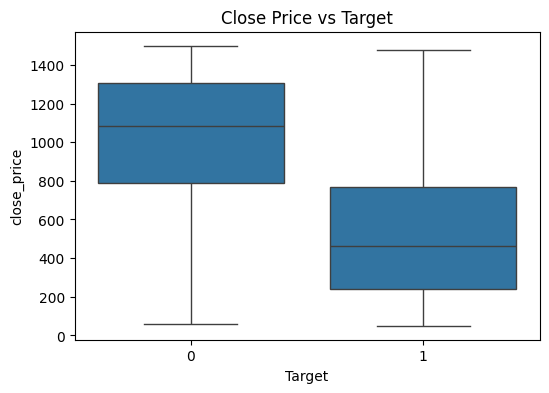

In [119]:

# Relação entre preço e Target
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Target', y='close_price')
plt.title('Close Price vs Target')
plt.show()

A respeito do desbalanceamento, o Dataset não apresenta desbalanceamento extremo entre as classes Alta (1) e Baixa (0), entre as empresas analisadas e os conjuntos de dados analisados.


Por se tratar de uma variável binária, não há aplicação de análise de outliers para o <b><i>Target</i></b>. Já as variáveis numéricas apresentam valores extremos esperados, o que é comum em dados financeiros devido à volatilidade do mercado.


O boxplot evidencia que a variável <i><b>close_price</i></b> apresenta maior distinção entre as classes, refletindo sua relação com a construção da variável Target.

Em relação aos padrões, não foram identificadas diferenças expressivas entre as empresas apenas com base na Target, indicando um comportamento relativamente consistente do Dataset.



### Conclusões da análise exploratória

De modo geral, esse Dataset apresenta uma boa adequação para a etapa de modelagem, não sendo identificados problemas relevantes como valores ausentes ou inconsistências estruturais significativas durante a análise exploratória..

Essa qualidade permite seguir para a modelagem, com os desdobramentos:<br>
- Pré-processamento dos dados.
- Treinamento dos modelos.
- Avaliação de desempenho.
- Interpretação dos resultados.




# Preparação dos dados e divisão treino/teste

Como já mencionado, o objetivo do modelo é prever a variável Target, que representa a direção futura do preço do ativo no período seguinte, sendo classificada como Alta (1) ou Baixa (0).

Dessa forma, a variável Target foi definida como variável resposta <i><b>Target</i></b>, enquanto as demais colunas foram utilizadas como variáveis preditoras <i><b>Features</i></b>.

Além disso, algumas técnicas de pré-processamento serão aplicadas antes da divisão dos dados.

In [120]:
# ordenação temporal por empresa e data
df = df.sort_values(["company", "date"]).reset_index(drop=True)

# one-ot encod. para var. categóricas
df = pd.get_dummies(
    df,
    columns=["company", "market_sentiment"],
    dtype=int
)
# separação de features e target
X = df.drop(columns=["Target"])
y = df["Target"]

Inicialmente, o conjunto de dados foi ordenado por empresa e data, garantindo a preservação da estrutura temporal de cada ativo e assegurando que as observações estejam organizadas de forma cronológica.

Em seguida, as variáveis categóricas <i><b>'company'</i></b> e <i><b>'market_sentiment'</i></b> foram transformadas com a aplicação da técnica One-Hot Encoding, convertendo cada categoria em variáveis binárias.

Por fim, o conjunto de dados foi separado em <i><b>variáveis explicativas (X) </i></b> e <i><b>variável alvo (y)</i></b>, onde X contém todas as features utilizadas para a predição e y representa a variável Target, que indica a direção do preço no próximo período.


## Justificativa da divisão

Após a preparação dos dados, ocorre a divisão do conjunto em dados de treinamento e teste - 80% treino/ 20% teste, para o desenvolvimento do modelo de Machine Learning.



In [122]:
# Divisão temporal (80% treino / 20% teste)
train_size = int(len(X) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]


Foi calculado o número de observações correspondente a 80% do Dataset, definindo o tamanho do conjunto de treinamento. Em seguida, as variáveis <i><b>explicativas (X) </i></b>e a <i><b>variável alvo (y)</i></b>foram divididas de forma sequencial, destinando os primeiros 80% dos registros para o treinamento do modelo e os 20% restantes para a etapa de teste.
Dessa forma, foram obtidos os conjuntos <i><b>X_train</i></b>, <i><b>X_test</i></b>,<i><b> y_train</i></b> e<i><b> y_test</i></b>.

A divisão foi realizada utilizando o método holdout com separação temporal,preservando a ordem cronológica dos dados. Isso evita que as informações de períodos futuos sejam utilizadas durante o treinamento do modelo.

Como os dados possuem natureza temporal, não foi aplicada a estratificação das classes, pois a prioridade é preservar a ordem cronológica dos registros. Essa divisão também evita o vazamento de informação (data leakage), garantindo que o modelo seja treinado com dados passados e avaliado em dados futuros.


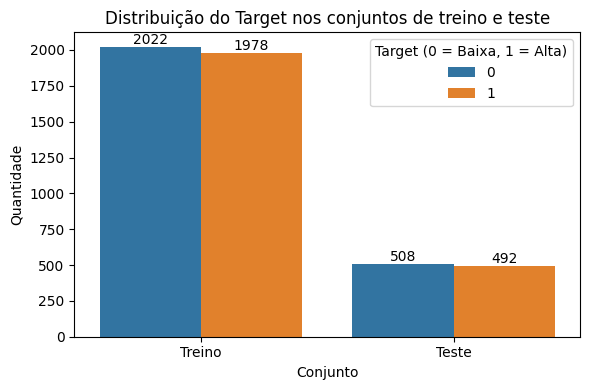

In [125]:
 # dist. do Target nos conjuntos de treino e teste
df_plot = pd.DataFrame({
    "Target": pd.concat([y_train, y_test]),
    "Conjunto": (["Treino"] * len(y_train)) + (["Teste"] * len(y_test))
})

plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df_plot,
    x="Conjunto",
    hue="Target"
)

plt.title("Distribuição do Target nos conjuntos de treino e teste")
plt.xlabel("Conjunto")
plt.ylabel("Quantidade")
plt.legend(title="Target (0 = Baixa, 1 = Alta)")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

Observa-se que a divisão temporal manteve uma distribuição semelhante das classes Alta (1) e Baixa (0) nos conjuntos de treinamento e teste, preservando o equilíbrio da variável alvo.

No conjunto de treinamento:
- 2.022 registros da classe 0  
- 1.978 da classe 1

No conjunto de teste:
- 508 registros da classe 0
- 492 da classe 1



# Pipeline de machine learning

#  Baseline e modelos candidatos

##  Justificativa dos modelos

# Treinamento e avaliação inicial

# Validação e otimização de hiperparâmetros

# Avaliação final no conjunto de teste

# Comparação final dos modelos

# Boas práticas e rastreabilidade

# Conclusão